In [382]:
# as we have image size with 128*128 dimension that mean number of pixel will be around 128*128 = 16,384 pixels. While working with images
# each pixel will be treated as independent variable/feature. So total number of features will be 16,384.

In [383]:
from datasets import load_from_disk
import numpy as np
from sklearn.decomposition import  PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,classification_report
import matplotlib.pyplot as plt
from PIL import Image
from collections import Counter
from sklearn.metrics import accuracy_score, f1_score,confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix
import pandas as pd


In [384]:
dataset = load_from_disk("dataset")

In [385]:
dataset

DatasetDict({
    train: Dataset({
        features: ['image', 'label'],
        num_rows: 4096
    })
    test: Dataset({
        features: ['image', 'label'],
        num_rows: 1280
    })
    aug: Dataset({
        features: ['image', 'label'],
        num_rows: 4096
    })
    valid: Dataset({
        features: ['image', 'label'],
        num_rows: 1024
    })
})

In [386]:
train = dataset["train"]

In [387]:
train

Dataset({
    features: ['image', 'label'],
    num_rows: 4096
})

In [388]:
images = []

# looping through each data and appending image in images array
for data in train:
    img = data["image"]
    images.append(img)


In [389]:
# changing image value in numpy array
X_train = np.array(images,dtype=np.float32)

In [390]:
# each image is 128x128 size array which is 2D. so we need make 1D array 'cause linear regression expect 1D array
X_train.shape 

(4096, 128, 128)

In [391]:
X = X_train.reshape(X_train.shape[0],-1)
X.shape

(4096, 16384)

In [392]:
# normalizing the value that ranges from 0-255 to 0-1 
X = X/255.0

In [393]:
# So,features size will be number of pixel size so, next move to decrease the number of feature size using PCA(Principal Component Analysis).

In [394]:
# setting threshold value to 0.9 that means we calculate component that have 90% variance ratio.
X_pca = PCA(n_components=0.9)

In [395]:
# fitting our data to PCA
X_train_pca = X_pca.fit_transform(X)

In [396]:
X_train_pca
print("Components", len(X_pca.explained_variance_ratio_))
X_train_pca.shape

Components 372


(4096, 372)

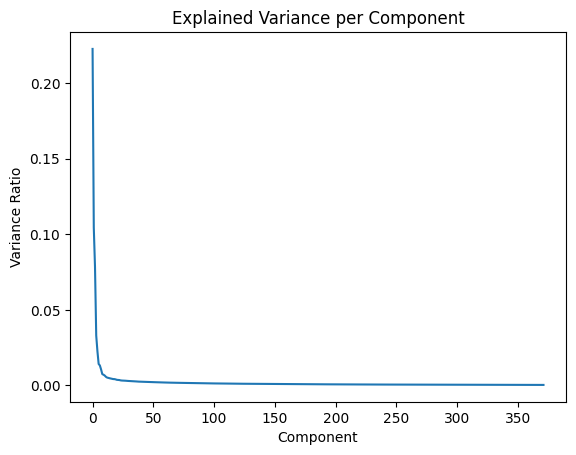

Total variance retained: 0.90012896


In [397]:
plt.plot(X_pca.explained_variance_ratio_)
plt.title("Explained Variance per Component")
plt.xlabel("Component")
plt.ylabel("Variance Ratio")
plt.show()

print("Total variance retained:", np.sum(X_pca.explained_variance_ratio_))



In [398]:
# Here we put a threshold to find number of component that preserve our most of variance, threshold was 90% where we 372 component.
# Though we decrease our feature size from 128*128 = 16384 to 372 we still have change of overfitting here.

In [399]:
# getting labels list
Y = []
for d in train:
    Y.append(d["label"])

In [400]:
len(Y)

4096

In [401]:
model = LogisticRegression(max_iter=1000)

In [402]:
# X_train_val_pca = X_pca.transform(X)
model.fit(X_train_pca,Y)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [403]:
pred_y = model.predict(X_train_val_pca)

In [404]:
print("Accuracy:", accuracy_score(Y, pred_y))
print(classification_report(Y, pred_y))

Accuracy: 0.87255859375
              precision    recall  f1-score   support

           0       0.94      0.93      0.93       579
           1       1.00      1.00      1.00        43
           2       0.87      0.90      0.89      2044
           3       0.84      0.81      0.83      1430

    accuracy                           0.87      4096
   macro avg       0.91      0.91      0.91      4096
weighted avg       0.87      0.87      0.87      4096



In [405]:
# using validation dataset to test on model that we train on training dataset
dataset

DatasetDict({
    train: Dataset({
        features: ['image', 'label'],
        num_rows: 4096
    })
    test: Dataset({
        features: ['image', 'label'],
        num_rows: 1280
    })
    aug: Dataset({
        features: ['image', 'label'],
        num_rows: 4096
    })
    valid: Dataset({
        features: ['image', 'label'],
        num_rows: 1024
    })
})

In [406]:
# validation dataset
val_data = dataset["valid"]
len(val_data)

1024

In [407]:
val_X = []
val_Y = []

In [408]:
for d in val_data:
    val_X.append(d["image"])
    val_Y.append(d["label"])

In [409]:
len(val_X) == len(val_Y)
# so val_X contains images so need to change it numpy array
val_X = np.array(val_X,dtype=np.float32)

In [410]:
# same in train dataset validation dataset also have 128X128 value so we need to flatten that and normalizate it.


In [411]:
# normalizing the value of val_X
val_X = val_X.reshape(val_X.shape[0],-1)
val_X = val_X/255.0

In [412]:
# fitting val_X in pca
val_X_pca = X_pca.transform(val_X)

In [413]:
# predicting the value of using our 1st model that was trained using training data only
val_y_predict = model.predict(val_X_pca)

In [414]:
print("Accuracy value for Validation dataset", accuracy_score(val_Y, val_y_predict))
print(classification_report(val_Y, val_y_predict))

Accuracy value for Validation dataset 0.7880859375
              precision    recall  f1-score   support

           0       0.76      0.80      0.78       145
           1       1.00      1.00      1.00         6
           2       0.83      0.82      0.82       522
           3       0.74      0.74      0.74       351

    accuracy                           0.79      1024
   macro avg       0.83      0.84      0.83      1024
weighted avg       0.79      0.79      0.79      1024



In [415]:
# As accuracy result on validation is lower than what we got in training dataset which was around 0.87 > 0.78
# second thing is with class 1 with only 6 data of class 1, we are getting precision call,recall and f1-score 1. That means we have
# overfitting on model.

In [416]:
# Next step is to use class_weight = "balanced" during our logistic regression in with training set retrain the model and check with
# validation dataset again

In [417]:
# model 2 balanced
balance_model = LogisticRegression(max_iter=1000,class_weight="balanced")

In [418]:
balance_model.fit(X_train_val_pca,Y)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :ter

In [419]:
val_y_bal_predict = balance_model.predict(val_X_pca)

In [420]:
print("Accuracy value for Validation dataset", accuracy_score(val_Y, val_y_bal_predict))
print(classification_report(val_Y, val_y_bal_predict))

Accuracy value for Validation dataset 0.765625
              precision    recall  f1-score   support

           0       0.69      0.85      0.76       145
           1       1.00      1.00      1.00         6
           2       0.84      0.76      0.80       522
           3       0.71      0.74      0.72       351

    accuracy                           0.77      1024
   macro avg       0.81      0.84      0.82      1024
weighted avg       0.77      0.77      0.77      1024



In [421]:
# after balanced f1 score for class 0 is decreased from 0.78 to 0.76 but recall is increased from 0.80 to 0.85 where for class 1 remain same
# and class 2 recall is dropped as trade-off with accuracy decrease from 0.78 to 0.77

In [422]:
# lets augment data with train data, see how well does model works

In [423]:
dataset

DatasetDict({
    train: Dataset({
        features: ['image', 'label'],
        num_rows: 4096
    })
    test: Dataset({
        features: ['image', 'label'],
        num_rows: 1280
    })
    aug: Dataset({
        features: ['image', 'label'],
        num_rows: 4096
    })
    valid: Dataset({
        features: ['image', 'label'],
        num_rows: 1024
    })
})

size = (128, 128)
channel = RGB


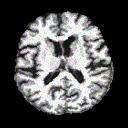

In [424]:
aug = dataset["aug"]
# checking dimension and channels of images in aug
first_aug_image = aug[0]["image"]

print(f"size = {first_aug_image.size}")
print(f"channel = {first_aug_image.mode}")
first_aug_image

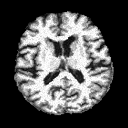

In [425]:
aug_X = []
aug_Y = []


for au in aug:
    img_rgb =au["image"]
    # converting into grayscale image as we found that image that are in aug is RGB

    # extra
    # h, w, c = img_rgb.shape
    # pixels = img_rgb.reshape(-1, c)
    # rgb_image_pca = PCA(n_components=1)
    # img_gray_flat = rgb_image_pca.fit_transform(pixels)
    # img_gray = img_gray_flat.reshape(h, w)
    # img_gray = ((img_gray - img_gray.min()) / (img_gray.max() - img_gray.min()) * 255).astype(np.uint8)
    # extra


    
    img_gray = au["image"].convert("L")
    aug_X.append(img_gray)
    aug_Y.append(au["label"])

aug_X[0]


In [426]:
# changing into numpy array
aug_X = np.array(aug_X,dtype=np.float32)
# flatten aug_X array to 1D 
aug_X = aug_X/255.0
aug_X = aug_X.reshape(aug_X.shape[0],-1)


In [427]:
train_aug_X = np.concatenate([X,aug_X])

In [428]:
train_aug_Y = np.concatenate([Y,aug_Y])
print("Train distribution:", Counter(train_aug_Y))

Train distribution: Counter({np.int64(2): 4088, np.int64(3): 2860, np.int64(0): 1158, np.int64(1): 86})


In [448]:
new_pca = PCA(n_components=200)
train_aug_pca = new_pca.fit_transform(train_aug_X)

In [449]:
model_train_aug = LogisticRegression(max_iter=1000)


In [450]:
model_train_aug.fit(train_aug_pca,train_aug_Y)

# new val X pca
new_val_pca = new_pca.transform(val_X)

In [451]:
val_y_bal_predict_2 = model_train_aug.predict(new_val_pca)

Accuracy value for Validation dataset 0.64453125
              precision    recall  f1-score   support

           0       0.51      0.34      0.40       145
           1       1.00      0.83      0.91         6
           2       0.73      0.77      0.75       522
           3       0.56      0.58      0.57       351

    accuracy                           0.64      1024
   macro avg       0.70      0.63      0.66      1024
weighted avg       0.64      0.64      0.64      1024



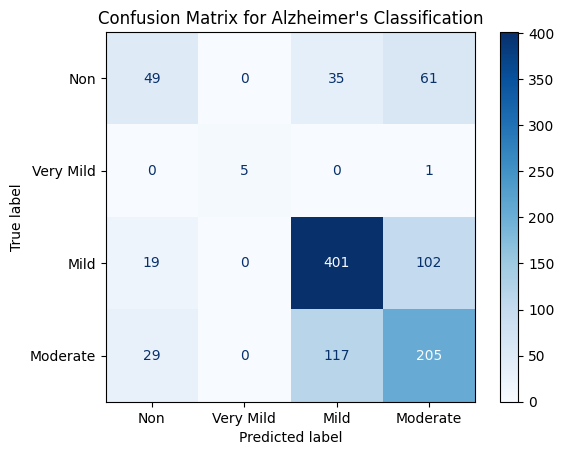

In [452]:
print("Accuracy value for Validation dataset", accuracy_score(val_Y, val_y_bal_predict_2))
print(classification_report(val_Y, val_y_bal_predict_2))
cm = confusion_matrix(val_Y, val_y_bal_predict_2)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Non", "Very Mild", "Mild", "Moderate"]) 
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix for Alzheimer's Classification")
plt.show()

In [453]:
# after training three model
# Model 1 - trained on training dataset - predicting validation data - accuracy = 0.78
# Model 2 - trained with balanced training dataset - predicting validation data - accuracy = 0.76
# model 3 - trained with training + augment dataset - predicting validation dataset - accuracy = 0.59

In [454]:
# as after adding augmentation data, the accuracy decrease to 0.65 so we are going to add regularization

results = []

for c in [0.01, 0.1, 1, 10,100]:
    reg_model = LogisticRegression(
        C=c,
        max_iter=5000,

    )
    reg_model.fit(train_aug_pca, train_aug_Y)
    val_pred_1 = reg_model.predict(new_val_pca)
    acc = accuracy_score(val_Y, val_pred_1)
    f1 = f1_score(val_Y, val_pred_1, average="macro")
    
    results.append((c, acc, f1))
    
    print(f"C = {c}")
    print("Accuracy-", acc)
    print("Macro F1-", f1)
  



C = 0.01
Accuracy- 0.6337890625
Macro F1- 0.48923743723413426
C = 0.1
Accuracy- 0.64453125
Macro F1- 0.6576568620939043
C = 1
Accuracy- 0.64453125
Macro F1- 0.6573851357123026
C = 10
Accuracy- 0.6435546875
Macro F1- 0.6299149589096016
C = 100
Accuracy- 0.64453125
Macro F1- 0.6573851357123026


In [465]:
# working with test data
dataset


DatasetDict({
    train: Dataset({
        features: ['image', 'label'],
        num_rows: 4096
    })
    test: Dataset({
        features: ['image', 'label'],
        num_rows: 1280
    })
    aug: Dataset({
        features: ['image', 'label'],
        num_rows: 4096
    })
    valid: Dataset({
        features: ['image', 'label'],
        num_rows: 1024
    })
})

In [466]:
test = dataset["test"]
test[0]["image"].mode


'L'

In [467]:
test_X = []
test_Y = []

for i_t in test:
    test_X.append(i_t["image"])
    test_Y.append(i_t["label"])

In [468]:
test_X = np.array(test_X,dtype=np.float32)

In [469]:
test_X = test_X/255.0
test_X = test_X.reshape(test_X.shape[0],-1)

In [470]:
# creating pca only with PCA which was fitted only using training dataset
test_pca = X_pca.transform(test_X)

In [471]:
test_predicition = model.predict(test_pca)

Accuracy value for Validation dataset 0.78671875
              precision    recall  f1-score   support

           0       0.78      0.75      0.77       172
           1       1.00      0.93      0.97        15
           2       0.81      0.85      0.83       634
           3       0.75      0.71      0.73       459

    accuracy                           0.79      1280
   macro avg       0.83      0.81      0.82      1280
weighted avg       0.79      0.79      0.79      1280



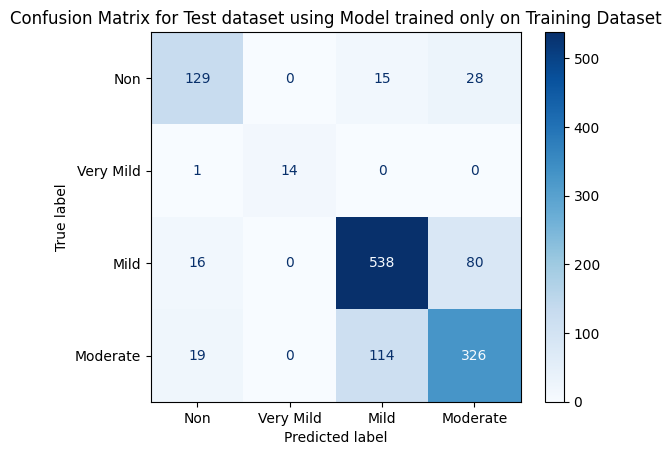

In [474]:
print("Accuracy value for Validation dataset", accuracy_score(test_Y, test_predicition))
print(classification_report(test_Y, test_predicition))
cm_test = confusion_matrix(test_Y, test_predicition)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_test, display_labels=["Non", "Very Mild", "Mild", "Moderate"]) 
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix for Test dataset using Model trained only on Training Dataset")
plt.show()

Accuracy value for Validation dataset 0.63984375
              precision    recall  f1-score   support

           0       0.56      0.33      0.42       172
           1       1.00      0.87      0.93        15
           2       0.68      0.79      0.73       634
           3       0.57      0.54      0.55       459

    accuracy                           0.64      1280
   macro avg       0.70      0.63      0.66      1280
weighted avg       0.63      0.64      0.63      1280



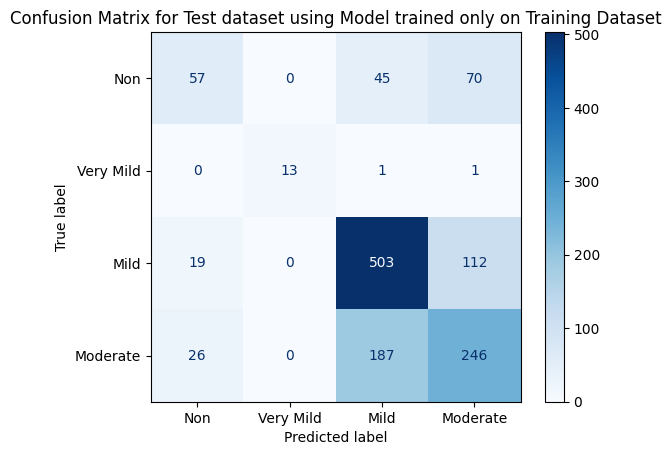

In [476]:
# creating PCA for test_X that was fitted using training+augment dataset
test_aug_train_pca = new_pca.transform(test_X)

test_aug_train_model = model_train_aug.predict(test_aug_train_pca)
print("Accuracy value for Validation dataset", accuracy_score(test_Y, test_aug_train_model))
print(classification_report(test_Y, test_aug_train_model))
cm_test_2 = confusion_matrix(test_Y, test_aug_train_model)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_test_2, display_labels=["Non", "Very Mild", "Mild", "Moderate"]) 
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix for Test dataset using Model trained only on Training Dataset")
plt.show()
